# Q1 — Tokenisation and Justification of Method

**CT107-3-3-TXSA — Group Assignment, Part A**

This notebook addresses:

- **Q1 Part 1 (2 marks):** Demonstrate word tokenisation on `Data_1.txt` using `split()`, Regular Expressions, and NLTK `word_tokenize()` — separately, with the output of each reported.
- **Q1 Part 2 (3 marks):** Justify the most suitable tokenisation method for text analytics, supported by the obtained outputs.

**Data source:** `Data_1.txt` (must be in the same folder as this notebook)


In [ ]:
print("=" * 60)
print("CELL 1: SETUP")
print("=" * 60)

# Import required libraries for tokenisation, data handling and plotting
try:
    import re
    import string
    import nltk
    import pandas as pd
    import matplotlib.pyplot as plt
    print("✓ All libraries imported successfully")
except ImportError as e:
    print(f"✗ Import error: {e}")

# Download the NLTK resources needed for word_tokenize (quiet = no progress spam)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✓ Setup complete")
print("=" * 60)


CELL 1: SETUP


✓ All libraries imported successfully


✓ Setup complete


In [ ]:
print("=" * 60)
print("CELL 2: LOAD DATA FROM Data_1.txt")
print("=" * 60)

# Read the raw text data from Data_1.txt (must be in the same folder as this notebook)
try:
    with open('Data_1.txt', 'r') as f:
        text = f.read()
except FileNotFoundError:
    print("✗ Error: 'Data_1.txt' not found. Make sure it is in the same folder as this notebook.")
    text = ""

print("\nRAW TEXT:")
print(text)

# Basic statistics about the raw text
print(f"\nCharacter count        : {len(text)}")
print(f"Approximate word count : {len(text.split())}")
print("=" * 60)


CELL 2: LOAD DATA FROM Data_1.txt

RAW TEXT:
Classification is the task of choosing the correct class label for a given input. In basic
classification tasks, each input is considered in isolation from all other inputs, and the set of labels is defined in advance. The basic classification task has a number of interesting variants. For example, in multiclass classification, each instance may be assigned multiple labels; in open-class classification, the set of labels is not defined in advance; and in sequence classification, a list of inputs are jointly classified.

Character count        : 524
Approximate word count : 82


In [ ]:
print("=" * 60)
print("METHOD 1: TOKENISATION USING split()")
print("=" * 60)

# split() breaks the text on whitespace only -- punctuation stays attached to words
tokens_split = text.split()

# Print every token with its index number
for i, token in enumerate(tokens_split, start=1):
    print(f"{i:5}. {token}")

print(f"\n  -> Total tokens: {len(tokens_split)}")

# A token "still has punctuation attached" if its last character is a punctuation mark
punct_attached = [token for token in tokens_split if token[-1] in string.punctuation]
print("  ! Tokens with punctuation still attached:")
print("      " + " | ".join(punct_attached))
print("=" * 60)


METHOD 1: TOKENISATION USING split()
    1. Classification
    2. is
    3. the
    4. task
    5. of
    6. choosing
    7. the
    8. correct
    9. class
   10. label
   11. for
   12. a
   13. given
   14. input.
   15. In
   16. basic
   17. classification
   18. tasks,
   19. each
   20. input
   21. is
   22. considered
   23. in
   24. isolation
   25. from
   26. all
   27. other
   28. inputs,
   29. and
   30. the
   31. set
   32. of
   33. labels
   34. is
   35. defined
   36. in
   37. advance.
   38. The
   39. basic
   40. classification
   41. task
   42. has
   43. a
   44. number
   45. of
   46. interesting
   47. variants.
   48. For
   49. example,
   50. in
   51. multiclass
   52. classification,
   53. each
   54. instance
   55. may
   56. be
   57. assigned
   58. multiple
   59. labels;
   60. in
   61. open-class
   62. classification,
   63. the
   64. set
   65. of
   66. labels
   67. is
   68. not
   69. defined
   70. in
   71. advance;
   72. and
   

In [ ]:
print("=" * 60)
print("METHOD 2: TOKENISATION USING REGULAR EXPRESSION")
print("=" * 60)

# This pattern matches maximal runs of alphabetic characters, discarding everything else
tokens_re = re.findall(r'\b[a-zA-Z]+\b', text)

# Print every token with its index number
for i, token in enumerate(tokens_re, start=1):
    print(f"{i:5}. {token}")

print(f"\n  -> Total tokens: {len(tokens_re)}")
print("  ! Note: punctuation (. , ; -) is completely removed by this pattern,")
print("    and hyphenated words (e.g. 'open-class') are split into two separate tokens.")
print("=" * 60)


METHOD 2: TOKENISATION USING REGULAR EXPRESSION
    1. Classification
    2. is
    3. the
    4. task
    5. of
    6. choosing
    7. the
    8. correct
    9. class
   10. label
   11. for
   12. a
   13. given
   14. input
   15. In
   16. basic
   17. classification
   18. tasks
   19. each
   20. input
   21. is
   22. considered
   23. in
   24. isolation
   25. from
   26. all
   27. other
   28. inputs
   29. and
   30. the
   31. set
   32. of
   33. labels
   34. is
   35. defined
   36. in
   37. advance
   38. The
   39. basic
   40. classification
   41. task
   42. has
   43. a
   44. number
   45. of
   46. interesting
   47. variants
   48. For
   49. example
   50. in
   51. multiclass
   52. classification
   53. each
   54. instance
   55. may
   56. be
   57. assigned
   58. multiple
   59. labels
   60. in
   61. open
   62. class
   63. classification
   64. the
   65. set
   66. of
   67. labels
   68. is
   69. not
   70. defined
   71. in
   72. advance
   73.

In [ ]:
print("=" * 60)
print("METHOD 3: TOKENISATION USING NLTK word_tokenize")
print("=" * 60)

# NLTK's word_tokenize uses Penn Treebank rules: punctuation becomes its own
# token, while hyphenated compounds are kept together as a single token
from nltk.tokenize import word_tokenize

tokens_nltk = word_tokenize(text)

# Print every token with its index number
for i, token in enumerate(tokens_nltk, start=1):
    print(f"{i:5}. {token}")

print(f"\n  -> Total tokens: {len(tokens_nltk)}")
print("  ! Note: punctuation marks (. , ;) are kept but separated out as their")
print("    own individual tokens, while hyphenated words such as 'open-class'")
print("    remain intact as a single token.")
print("=" * 60)


METHOD 3: TOKENISATION USING NLTK word_tokenize
    1. Classification
    2. is
    3. the
    4. task
    5. of
    6. choosing
    7. the
    8. correct
    9. class
   10. label
   11. for
   12. a
   13. given
   14. input
   15. .
   16. In
   17. basic
   18. classification
   19. tasks
   20. ,
   21. each
   22. input
   23. is
   24. considered
   25. in
   26. isolation
   27. from
   28. all
   29. other
   30. inputs
   31. ,
   32. and
   33. the
   34. set
   35. of
   36. labels
   37. is
   38. defined
   39. in
   40. advance
   41. .
   42. The
   43. basic
   44. classification
   45. task
   46. has
   47. a
   48. number
   49. of
   50. interesting
   51. variants
   52. .
   53. For
   54. example
   55. ,
   56. in
   57. multiclass
   58. classification
   59. ,
   60. each
   61. instance
   62. may
   63. be
   64. assigned
   65. multiple
   66. labels
   67. ;
   68. in
   69. open-class
   70. classification
   71. ,
   72. the
   73. set
   74. of
   75. 

In [ ]:
print("=" * 60)
print("COMPARISON OF TOKENISATION METHODS")
print("=" * 60)

# Build a comparison table summarising each method
comparison_df = pd.DataFrame({
    "Method": ["split()", "Regular Expression", "NLTK word_tokenize"],
    "Token Count": [len(tokens_split), len(tokens_re), len(tokens_nltk)],
    "Punctuation Handling": [
        "Stays attached to the word",
        "Completely removed",
        "Kept as a separate token"
    ],
    "Suitable for NLP": ["No", "Partial", "Yes"]
})

print(comparison_df.to_string(index=False))

# Show a specific example: how each method handles the word "advance" from the text
print("\n" + "-" * 60)
print('EXAMPLE: how each method handles "advance." / "advance;"')
print("-" * 60)

split_example = [t for t in tokens_split if "advance" in t]
re_example = [t for t in tokens_re if "advance" in t]

nltk_idx = [i for i, t in enumerate(tokens_nltk) if t == "advance"]
nltk_example = [(tokens_nltk[i], tokens_nltk[i + 1]) for i in nltk_idx]

print(f"  split()             -> {split_example}")
print(f"  Regular Expression  -> {re_example}")
print(f"  NLTK word_tokenize  -> {nltk_example}")
print("=" * 60)


COMPARISON OF TOKENISATION METHODS
            Method  Token Count       Punctuation Handling Suitable for NLP
           split()           82 Stays attached to the word               No
Regular Expression           83         Completely removed          Partial
NLTK word_tokenize           94   Kept as a separate token              Yes

------------------------------------------------------------
EXAMPLE: how each method handles "advance." / "advance;"
------------------------------------------------------------
  split()             -> ['advance.', 'advance;']
  Regular Expression  -> ['advance', 'advance']
  NLTK word_tokenize  -> [('advance', '.'), ('advance', ';')]


TOKEN COUNT COMPARISON CHART


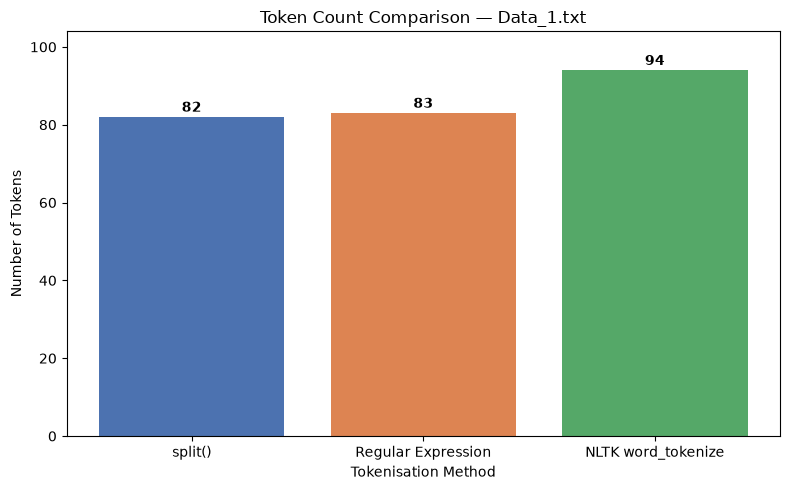

In [ ]:
print("=" * 60)
print("TOKEN COUNT COMPARISON CHART")
print("=" * 60)

# Prepare the data for the bar chart
methods = ["split()", "Regular Expression", "NLTK word_tokenize"]
counts = [len(tokens_split), len(tokens_re), len(tokens_nltk)]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, counts, color=colors)

# Add the token count as a label above each bar
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title("Token Count Comparison — Data_1.txt")
ax.set_xlabel("Tokenisation Method")
ax.set_ylabel("Number of Tokens")
ax.set_ylim(0, max(counts) + 10)

plt.tight_layout()
plt.savefig("Q1_Part1_chart.png")
plt.show()

print("=" * 60)


## Q1 Part 2 -- Justification of the Most Suitable Tokenisation Method 

### Verdict

**NLTK's `word_tokenize()` is the most suitable tokenisation method for text analytics.**

### Comparison Table

| Criterion | `split()` | Regular Expression `\b[a-zA-Z]+\b` | NLTK `word_tokenize()` |
|---|---|---|---|
| Token count (Data_1.txt) | 82 | 83 | **94** |
| Punctuation | Stays attached to the word (e.g. `advance.`, `labels;`) | Removed entirely | Separated into its own token (e.g. `advance` + `.`) |
| Hyphenated / compound words (e.g. `open-class`) | Preserved as one token | **Broken into two unrelated tokens** (`open`, `class`) | Preserved as one token (`open-class`) |
| Contractions (e.g. `don't`) | Kept as a single, inconsistent token | Split into `don` and `t`, losing meaning | Split linguistically (`do` + `n't`) |
| Ready for downstream NLP (POS tagging, stemming, vectorisation) | No | Partial | **Yes** |

### Evidence From Data_1.txt

1. **`"advance."` and `"advance;"`** -- With `split()`, these two occurrences of the word "advance" are stored as the *different* strings `advance.` and `advance;`. A bag-of-words model would therefore treat them as two separate, rare vocabulary items and would count the word "advance" itself **zero** times. NLTK's `word_tokenize()` correctly produces `advance` (x2) plus the punctuation marks `.` and `;` as their own tokens, so "advance" is counted twice as the *same* word.

2. **`"open-class"`** -- The regular expression `\b[a-zA-Z]+\b` cannot match across the hyphen, so `open-class` is broken into two separate tokens: `open` and `class`. This destroys the meaning of the compound term "open-class classification" -- the word `class` now becomes indistinguishable from every other occurrence of "class" in the text (e.g. in "class label"), even though they mean different things. NLTK's `word_tokenize()`, which follows Penn Treebank conventions, keeps `open-class` as a single token and preserves its compound meaning.

3. **`"variants."` and `"classified."`** -- As with "advance.", `split()` leaves the sentence-final full stop attached to the last word of each sentence (`variants.`, `classified.`). NLTK separates the `.` into its own token, which is essential for any later step that needs to detect sentence boundaries or cleanly remove punctuation (e.g. the stop-word/punctuation filtering required in Q1 Part 3).

### Why NLTK Follows Penn Treebank Rules

`word_tokenize()` internally uses NLTK's Treebank-style tokeniser, which applies linguistically motivated rules derived from the Penn Treebank corpus:

- Punctuation marks (`.`, `,`, `;`, `:`) are split off as separate tokens.
- Hyphenated compounds (`open-class`) are treated as single tokens, because the hyphen carries semantic meaning.
- Contractions (`don't`, `it's`) are split into their constituent morphemes (`do`/`n't`, `it`/`'s`), reflecting their grammatical structure.

This produces tokens that align with how words are actually used and analysed linguistically -- rather than tokens that are simply "whatever sits between two spaces" (`split()`) or "whatever matches a fixed character pattern" (regular expression).

### Why This Matters for Downstream NLP

- **POS tagging**: Taggers expect punctuation as separate tokens so that `.` can be assigned its own tag (sentence-final punctuation) independently of the preceding word.
- **Stemming / Lemmatisation**: A stemmer applied to the raw token `advance.` would not correctly reduce to its stem, because the trailing `.` corrupts the input.
- **Classification / Vectorisation**: Vocabulary-based models (bag-of-words, TF-IDF) need consistent token forms -- `advance`, `advance.`, and `advance;` must all map to the *same* feature, which only NLTK's output guarantees.

### Conclusion

NLTK's `word_tokenize()` produces the highest token count (94) precisely *because* it correctly separates punctuation from words while still preserving meaningful compound terms such as `open-class` -- something neither `split()` nor the regular-expression approach can achieve at the same time. For this reason, NLTK `word_tokenize()` is recommended as the most suitable tokenisation method for text analytics tasks such as stop-word filtering, POS tagging, and classification.

